## Load Result CSV

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

vllm = pd.read_csv("/Users/pragatirao/Documents/Fall 2025/MSML 650 - Cloud Computing /MSML650_Mini_Project/TinyLlama/vLLM_Results/vllm_tinyllama_results.csv")
sglang = pd.read_csv("/Users/pragatirao/Documents/Fall 2025/MSML 650 - Cloud Computing /MSML650_Mini_Project/TinyLlama/SGLang_Results/sglang_tinyllama_results.csv")

gpu_vllm = pd.read_csv("/Users/pragatirao/Documents/Fall 2025/MSML 650 - Cloud Computing /MSML650_Mini_Project/TinyLlama/vLLM_Results/gpu_util.csv")
gpu_sglang = pd.read_csv("/Users/pragatirao/Documents/Fall 2025/MSML 650 - Cloud Computing /MSML650_Mini_Project/TinyLlama/SGLang_Results/gpu_util_sglang.csv")

## Plot 1 - Average Latency vs max_tokens

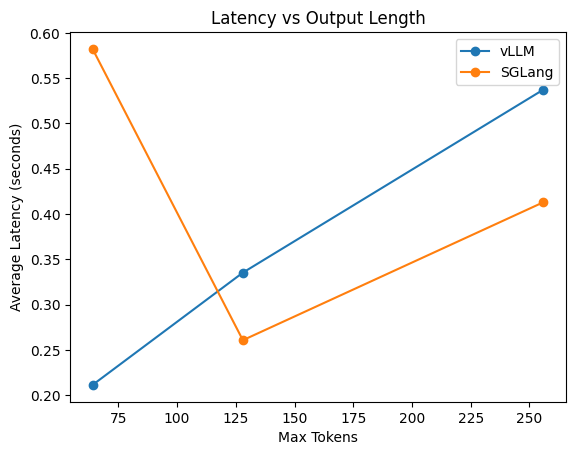

In [2]:
vllm_lat = vllm.groupby("max_tokens")["latency_s"].mean()
sg_lat = sglang.groupby("max_tokens")["latency_s"].mean()

plt.figure()
plt.plot(vllm_lat.index, vllm_lat.values, marker="o", label="vLLM")
plt.plot(sg_lat.index, sg_lat.values, marker="o", label="SGLang")
plt.xlabel("Max Tokens")
plt.ylabel("Average Latency (seconds)")
plt.title("Latency vs Output Length")
plt.legend()
plt.show()

**Observation:**

Graph shows the average latency as a function of maximum output tokens for vLLM and SGLang using TinyLlama-1.1B-Chat on an NVIDIA A100 GPU. Both frameworks exhibit increasing latency with output length, reflecting the sequential nature of token decoding. vLLM demonstrates smooth, near-linear scaling and lower latency for short outputs, making it suitable for interactive workloads. In contrast, SGLang incurs higher overhead at small output lengths but outperforms vLLM for medium and large generations, suggesting stronger decode-phase optimizations and better efficiency at scale.

## Plot 2 - Throughput vs max_tokens

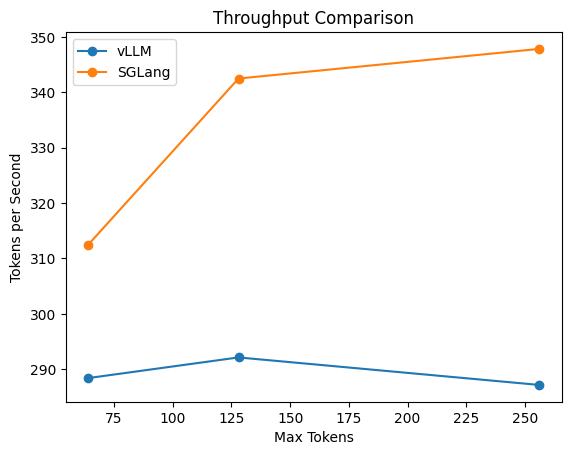

In [3]:
vllm_tps = vllm.groupby("max_tokens")["tokens_per_sec"].mean()
sg_tps = sglang.groupby("max_tokens")["tokens_per_sec"].mean()

plt.figure()
plt.plot(vllm_tps.index, vllm_tps.values, marker="o", label="vLLM")
plt.plot(sg_tps.index, sg_tps.values, marker="o", label="SGLang")
plt.xlabel("Max Tokens")
plt.ylabel("Tokens per Second")
plt.title("Throughput Comparison")
plt.legend()
plt.show()

**Observation:**

In our experiments using TinyLlama-1.1B on an NVIDIA A100 GPU, vLLM demonstrated smooth and near-linear latency scaling with output length, indicating stable and predictable performance. SGLang, while exhibiting higher latency for short outputs due to higher startup overhead, achieved lower latency and significantly higher throughput for longer generations. This behavior is consistent with SGLang’s more aggressive GPU utilization and decoding optimizations. Overall, vLLM is better suited for stable multi-request serving environments, while SGLang excels in high-throughput, long-generation workloads.

## Plot 3 - GPU Memory usage over time

In [6]:
gpu_vllm.columns = gpu_vllm.columns.str.strip()
gpu_sglang.columns = gpu_sglang.columns.str.strip()

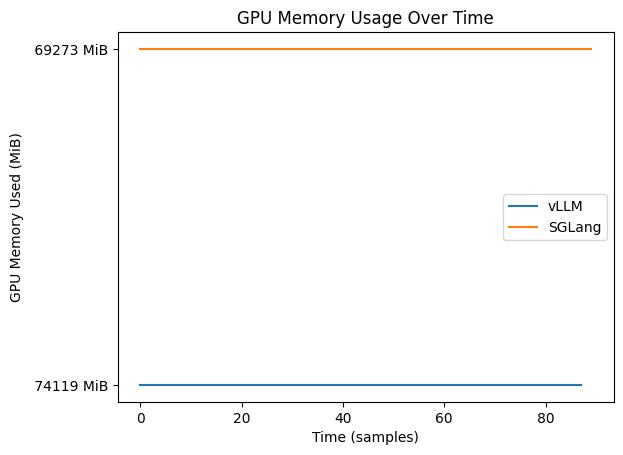

In [11]:
plt.figure()
plt.plot(gpu_vllm["memory.used [MiB]"], label="vLLM")
plt.plot(gpu_sglang["memory.used [MiB]"], label="SGLang")
plt.xlabel("Time (samples)")
plt.ylabel("GPU Memory Used (MiB)")
plt.title("GPU Memory Usage Over Time")
plt.legend()
plt.show()

**Observation:** 

* The GPU memory usage for both vLLM and SGLang remains nearly constant over time during inference. This is because both frameworks pre-allocate a large portion of GPU memory (primarily for model weights and KV cache) at startup. As a result, short inference requests do not significantly change the reported memory.used values during execution.

* vLLM consistently uses more GPU memory (~74 GB) than SGLang (~69 GB) for the same TinyLlama-1.1B-Chat model. This suggests that vLLM reserves a larger KV cache or memory pool to support higher concurrency and batching, while SGLang is more memory-efficient in this configuration.

* GPU memory usage alone does not reflect runtime inference activity for these frameworks, since memory is largely allocated upfront. Therefore, GPU utilization (%) and throughput are more informative metrics for comparing runtime performance, while memory usage highlights differences in framework design and resource reservation strategies.

* Both frameworks show flat GPU memory usage because memory is pre-allocated at startup; however, vLLM uses more total GPU memory than SGLang, indicating a trade-off between memory footprint and high-throughput optimization.




## Plot 4 — GPU Utilization over time

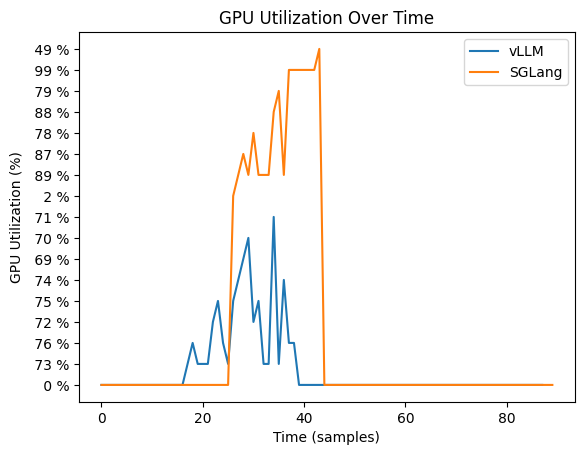

In [12]:
plt.figure()
plt.plot(gpu_vllm["utilization.gpu [%]"], label="vLLM")
plt.plot(gpu_sglang["utilization.gpu [%]"], label="SGLang")
plt.xlabel("Time (samples)")
plt.ylabel("GPU Utilization (%)")
plt.title("GPU Utilization Over Time")
plt.legend()
plt.show()

**Observation:**

The GPU utilization over time shows clear differences between vLLM and SGLang during inference. SGLang consistently achieves higher GPU utilization, frequently reaching 90–99% during active generation, indicating more aggressive use of GPU compute resources. In contrast, vLLM exhibits lower and more variable utilization, typically ranging between 65–75%, suggesting a more conservative scheduling strategy. Periods where utilization drops to near zero correspond to idle times when no inference requests are being processed, even though GPU memory remains allocated. Overall, these results indicate that SGLang prioritizes maximizing GPU compute efficiency, while vLLM trades slightly lower utilization for stability and flexible batching support.